In [1]:
import scanpy as sc
import os
import scanpy as sc
import pandas as p
import numpy as np
from scipy import sparse
os.getcwd()

'/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/Infer_plaque_type/0603_no_Basophil_state_score'

# with other unknown
整体流程（state_score 版本）

```text
第一步：生成 X_basic_celltype_proportion.csv 和 y_sample_label_numeric.csv
        ↓
中间这一步：生成 X_pseudobulk_marker.csv（原始 marker pseudobulk，保留作为原料）
        ↓
新增：用训练集 pseudobulk marker 计算 X_state_scores.csv
        ↓
再拼接生成 X_combined_basic_plus_state_scores.csv
        ↓
训练验证 LogisticRegression
        ↓
生成 unknown / new h5ad 的 state-score 特征并预测
```

注意：prediction data 的 state score 使用训练集 fit 出来的 gene-level mean/std 做 transform，不能对 prediction data 自己重新 fit。

In [2]:
def _mean_log_normalized_marker_expression(
    layer_matrix,
    library_size,
    row_idx,
    gene_idx,
    genes,
    target_sum=1e4,
):
    if len(genes) == 0:
        return pd.Series(dtype=float)

    row_library_size = library_size[row_idx]
    scale = np.divide(
        target_sum,
        row_library_size,
        out=np.zeros(row_idx.size, dtype=float),
        where=row_library_size > 0,
    )
    marker_counts = layer_matrix[row_idx, :][:, gene_idx]

    if sparse.issparse(marker_counts):
        marker_norm = marker_counts.multiply(scale[:, None]).tocsr()
        marker_norm.data = np.log1p(marker_norm.data)
        mean_expr = np.asarray(marker_norm.mean(axis=0)).ravel()
    else:
        marker_norm = np.log1p(np.asarray(marker_counts, dtype=float) * scale[:, None])
        mean_expr = np.asarray(marker_norm.mean(axis=0)).ravel()

    return pd.Series(mean_expr, index=genes)


def build_marker_dict_from_state_markers(state_markers):
    """Collapse state-level markers into celltype-level marker lists for pseudobulk features."""
    marker_dict = {}
    for info in state_markers.values():
        celltype = info["celltype"]
        marker_dict.setdefault(celltype, [])
        seen = set(marker_dict[celltype])
        for gene in info["genes"]:
            if gene not in seen:
                marker_dict[celltype].append(gene)
                seen.add(gene)
    return marker_dict


def standardize_gene_names_for_marker_features(
    adata_in,
    preferred_var_cols=("human_gene_name", "original_gene_names"),
):
    """Use human gene symbols for marker features, preferring mouse homolog annotations when available."""
    old_names = pd.Index(adata_in.var_names.astype(str))
    new_names = pd.Series(old_names, index=adata_in.var.index, dtype=str)
    selected_col = None

    if "original_feature_id" not in adata_in.var.columns:
        adata_in.var["original_feature_id"] = old_names.astype(str)

    for col in preferred_var_cols:
        if col not in adata_in.var.columns:
            continue
        raw_values = adata_in.var[col]
        names = raw_values.astype(str).str.strip()
        valid = raw_values.notna() & names.ne("") & ~names.str.lower().isin(["nan", "none"])
        if valid.any():
            new_names.loc[valid] = names.loc[valid]
            selected_col = col
            break

    renamed = old_names.to_series(index=adata_in.var.index).astype(str) != new_names.astype(str)
    n_renamed = int(renamed.sum())
    if selected_col is not None:
        print(f"Using adata.var['{selected_col}'] as marker gene names.")
    if n_renamed > 0:
        print(f"Updated {n_renamed} gene names for marker feature alignment.")

    adata_in.var_names = pd.Index(new_names.astype(str))
    adata_in.var_names_make_unique()
    return adata_in


def build_pseudobulk_features(
    adata_in,
    marker_dict,
    sample_col,
    celltype_col,
    include_ncells=False,
    expression_layer="raw_decontXcounts",
    target_sum=1e4,
):
    if expression_layer not in adata_in.layers:
        raise ValueError(f"adata.layers 缺少 {expression_layer!r}，不能生成 marker pseudobulk 特征。")

    layer_matrix = adata_in.layers[expression_layer]
    library_size = np.asarray(layer_matrix.sum(axis=1)).ravel()
    gene_to_idx = {gene: idx for idx, gene in enumerate(adata_in.var_names.astype(str))}
    sample_values = adata_in.obs[sample_col].astype(str).to_numpy()
    celltype_values = adata_in.obs[celltype_col].astype(str).to_numpy()

    print(
        f"Using log1p({expression_layer} / per-cell {expression_layer} library size * {target_sum:g}) "
        "for marker pseudobulk features."
    )

    all_genes = set(gene_to_idx)
    filtered_marker_dict, missing_marker_report = {}, {}
    for ct, genes in marker_dict.items():
        present = [g for g in genes if g in all_genes]
        missing = [g for g in genes if g not in all_genes]
        filtered_marker_dict[ct] = present
        missing_marker_report[ct] = missing
    print("\n===== marker presence check =====")
    for ct in marker_dict:
        print(f"{ct}:")
        print("  present:", filtered_marker_dict[ct])
        print("  missing:", missing_marker_report[ct])
    filtered_marker_dict = {ct: genes for ct, genes in filtered_marker_dict.items() if len(genes) > 0}
    all_celltypes = set(celltype_values)
    print("\n===== cell types in adata =====")
    print(sorted(list(all_celltypes))[:50])
    valid_celltypes = [ct for ct in filtered_marker_dict if ct in all_celltypes]
    invalid_celltypes = [ct for ct in filtered_marker_dict if ct not in all_celltypes]
    if len(invalid_celltypes) > 0:
        print("\n这些 marker_dict 里的 cell type 不在 adata.obs 里，请检查命名：")
        print(invalid_celltypes)
    filtered_marker_dict = {ct: filtered_marker_dict[ct] for ct in valid_celltypes}
    if len(filtered_marker_dict) == 0:
        raise ValueError("没有任何有效的 cell type + marker 组合。")

    feature_rows = []
    sample_ids = pd.Index(sample_values).unique().tolist()
    for sample_id in sample_ids:
        sample_mask = sample_values == str(sample_id)
        row_dict = {"sample": sample_id}
        for ct, genes in filtered_marker_dict.items():
            row_idx = np.flatnonzero(sample_mask & (celltype_values == ct))
            n_cells = int(row_idx.size)
            if n_cells == 0:
                for g in genes:
                    row_dict[f"pb__{ct}__{g}"] = np.nan
                if include_ncells:
                    row_dict[f"pb_ncells__{ct}"] = 0
                continue

            gene_idx = [gene_to_idx[g] for g in genes]
            mean_expr = _mean_log_normalized_marker_expression(
                layer_matrix,
                library_size,
                row_idx,
                gene_idx,
                genes,
                target_sum=target_sum,
            )
            for g in genes:
                row_dict[f"pb__{ct}__{g}"] = float(mean_expr[g])
            if include_ncells:
                row_dict[f"pb_ncells__{ct}"] = n_cells
        feature_rows.append(row_dict)

    X_pb = pd.DataFrame(feature_rows).set_index("sample")
    return X_pb


In [3]:
# =========================
# State score feature helpers
# =========================
# Keep X_pseudobulk_marker as the raw intermediate table, then compress marker genes
# into a smaller number of biologically grouped state scores.

STRICT_PLAQUE_STATE_MARKERS = {
    "Macrophage_PLIN2_TREM1_inflammatory_LAM": {
        "celltype": "Macrophage",
        "genes": ["PLIN2", "TREM1", "CCL2", "CXCL2", "CXCL3", "CXCL8", "TLR2", "IL1B"],
    },

    "Macrophage_TREM2_foamy_LAM": {
        "celltype": "Macrophage",
        "genes": ["TREM2", "CD36", "FABP4", "FABP5"],
    },

    "Macrophage_HMOX1_iron_heme_lipid": {
        "celltype": "Macrophage",
        "genes": [
            "HMOX1", "FTL", "SLC40A1", "NUPR1", "SELENOP", "PRDX1",
            "CTSB", "CTSD", "LAMP2", "LGMN", "LIPA", "GPNMB",
            "APOC2", "APOE", "LRP1", "NPC2"
        ],
    },

    "Monocyte_S100A8_IL1B_inflammatory": {
        "celltype": "Monocyte",
        "genes": [
            "S100A8", "S100A9", "S100A12", "IL1B", "NLRP3",
            "TNF", "CCL3", "CCL4", "CCL20", "CEBPB", "NFKB1", "TLR2",
            "CDKN1", "PTGER2", "PTGS2", "MCL1"
        ],
    },

    "SMC_TCF21_fibromyocyte_modulation": {
        "celltype": "Smooth muscle cell",
        "genes": ["TCF21"],
    },

    "EC_proangiogenic_venous": {
        "celltype": "Endothelial cell",
        "genes": ["ACKR1", "AQP1", "FABP4", "NR2F2"],
    },

    "EC_EndoMT_arterial": {
        "celltype": "Endothelial cell",
        "genes": ["COL1A2", "FN1", "GJA4", "GJA5", "MECOM", "GATA2"],
    },

    "Tcell_resident_activated_exhausted": {
        "celltype": "T cell",
        "genes": ["CCL5", "CD69", "NR3C1", "PDCD1", "KLRG1", "GZMK"],
    },

    "Tcell_CD4_exhaustion_like": {
        "celltype": "T cell",
        "genes": ["CXCL13", "NR3C1", "PDCD1"],
    },

    "Tcell_CD8_TEM_activation": {
        "celltype": "T cell",
        "genes": ["GZMK", "IFNG"],
    },

    "Tcell_IFN_response": {
        "celltype": "T cell",
        "genes": ["ISG15"],
    },

    "Tcell_MAIT_like": {
        "celltype": "T cell",
        "genes": ["KLRB1", "ZBTB16", "RORA", "SLC4A10"],
    },
}

STATE_MARKERS = STRICT_PLAQUE_STATE_MARKERS
marker_dict = build_marker_dict_from_state_markers(STATE_MARKERS)

# Some strict states intentionally contain one marker gene, so the minimum must allow them.
STATE_SCORE_MIN_GENES = 1


def _state_columns(x_pb, state_markers, min_genes=1):
    state_to_columns = {}
    report_rows = []

    for state_name, info in state_markers.items():
        celltype = info["celltype"]
        genes = info["genes"]
        columns = [f"pb__{celltype}__{gene}" for gene in genes]
        present = [col for col in columns if col in x_pb.columns]
        missing = [col for col in columns if col not in x_pb.columns]
        all_nan = [col for col in present if not x_pb[col].notna().any()]
        usable = [col for col in present if col not in all_nan]
        used = len(usable) >= min_genes

        if used:
            state_to_columns[state_name] = usable

        report_rows.append({
            "state": state_name,
            "celltype": celltype,
            "n_requested_genes": len(genes),
            "n_present_genes": len(present),
            "n_usable_genes": len(usable),
            "n_all_nan_genes": len(all_nan),
            "used": used,
            "present_columns": ";".join(present),
            "usable_columns": ";".join(usable),
            "all_nan_columns": ";".join(all_nan),
            "missing_columns": ";".join(missing),
        })

    return state_to_columns, report_rows


def fit_state_score_params(x_pb_train, state_markers=STATE_MARKERS, min_genes=STATE_SCORE_MIN_GENES):
    state_to_columns, report_rows = _state_columns(x_pb_train, state_markers, min_genes=min_genes)
    params = {}

    for state_name, columns in state_to_columns.items():
        mean = x_pb_train[columns].mean(axis=0)
        std = x_pb_train[columns].std(axis=0, ddof=0).replace(0, 1).fillna(1)
        params[state_name] = {
            "columns": columns,
            "mean": mean,
            "std": std,
        }

    return params, pd.DataFrame(report_rows)


def transform_state_scores(x_pb_data, params):
    scores = pd.DataFrame(index=x_pb_data.index)

    for state_name, state_params in params.items():
        columns = state_params["columns"]
        mean = state_params["mean"]
        std = state_params["std"]

        values = x_pb_data.reindex(columns=columns)
        values = values.fillna(mean)
        z_values = (values - mean) / std
        scores[f"score__{state_name}"] = z_values.mean(axis=1)

    return scores


def make_state_score_features(x_basic_part, x_pb_part, params):
    state_scores = transform_state_scores(x_pb_part, params)
    return pd.concat([x_basic_part, state_scores], axis=1)


def save_state_score_scaling_params(params, out_path):
    rows = []
    for state_name, state_params in params.items():
        for col in state_params["columns"]:
            rows.append({
                "state": state_name,
                "column": col,
                "mean": float(state_params["mean"].loc[col]),
                "std": float(state_params["std"].loc[col]),
            })
    pd.DataFrame(rows).to_csv(out_path, index=False)


## Plaque state-score rationale

这里以 `STRICT_PLAQUE_STATE_MARKERS` 作为唯一 marker 来源。`marker_dict` 从 `STATE_MARKERS` 自动按 cell type 去重生成，先产出 `X_pseudobulk_marker`，再用训练集 pseudobulk marker fit gene-level mean/std 并转换为 `X_state_scores`。mouse homolog 数据优先使用 `adata.var["human_gene_name"]` 作为基因名来和 human 训练特征对齐。

## prepare input

In [4]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse

# ========================= 参数 =========================
H5AD_PATH = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/0521_no_Basophil/output_allhuman/scPoli_concat_level3_marker_all_metadata.h5ad"
OUT_DIR = "./output_marker_state_score_2/"
os.makedirs(OUT_DIR, exist_ok=True)

SAMPLE_COL = "sample"
# CELLTYPE_COL = "cell_type_level1"
CELLTYPE_COL = "cell_type_level1_corrected"  # 应该用 cell_type_level1_corrected
LABEL_RAW_COL = "Plaque_type"
LABEL_COL = "Plaque_type_clean"

TRAIN_X_BASIC_PATH = f"{OUT_DIR}/X_basic_celltype_proportion.csv"
TRAIN_X_PB_PATH = f"{OUT_DIR}/X_pseudobulk_marker.csv"
TRAIN_X_STATE_PATH = f"{OUT_DIR}/X_state_scores.csv"
TRAIN_X_COMBINED_PATH = f"{OUT_DIR}/X_combined_basic_plus_state_scores.csv"
Y_LABEL_PATH = f"{OUT_DIR}/y_sample_label.csv"
Y_NUM_PATH = f"{OUT_DIR}/y_sample_label_numeric.csv"
STATE_MARKER_REPORT_PATH = f"{OUT_DIR}/state_score_marker_report.csv"
STATE_SCALING_PATH = f"{OUT_DIR}/state_score_scaling_params.csv"

OUT_X_BASIC_UNKNOWN = f"{OUT_DIR}/X_basic_unknown_celltype_proportion.csv"
OUT_X_PB_UNKNOWN = f"{OUT_DIR}/X_pseudobulk_marker_unknown.csv"
OUT_X_STATE_UNKNOWN = f"{OUT_DIR}/X_state_scores_unknown.csv"
OUT_X_UNKNOWN_COMBINED = f"{OUT_DIR}/X_unknown_combined_basic_plus_state_scores.csv"

marker_dict = build_marker_dict_from_state_markers(STATE_MARKERS)

# ========================= 1. 读取和预处理 h5ad =========================
print("Reading h5ad...")
adata = sc.read_h5ad(H5AD_PATH)
adata = adata[adata.obs[CELLTYPE_COL] != "unknown"].copy()
adata.var["original_feature_id"] = adata.var_names.astype(str)
adata.var_names = adata.var["original_gene_names"].astype(str)
adata.var_names_make_unique()
adata = standardize_gene_names_for_marker_features(adata)
adata.obs[LABEL_COL] = adata.obs[LABEL_RAW_COL].astype(str).str.strip().str.lower()

adata.obs[LABEL_COL] = adata.obs[LABEL_COL].replace({
    "nan": "unknown",
    "na": "unknown",
    "none": "unknown",
    "": "unknown",
    "unknown": "unknown",
    "Unknown": "unknown",
})
adata.obs[LABEL_COL] = adata.obs[LABEL_COL].fillna("unknown")

required_cols = [SAMPLE_COL, CELLTYPE_COL, LABEL_COL]
missing_cols = [c for c in required_cols if c not in adata.obs.columns]
if len(missing_cols) > 0:
    raise ValueError(f"adata.obs 缺少这些列: {missing_cols}")

print("adata shape after filtering unknown cell type:", adata.shape)
print("sample label distribution:")
print(adata.obs[LABEL_COL].value_counts(dropna=False))

# ========================= 2. 生成训练集 X_basic 和 y =========================
print("\nBuilding training X_basic and y...")
obs = adata.obs[[SAMPLE_COL, CELLTYPE_COL, LABEL_COL]].copy()
obs = obs.dropna(subset=[SAMPLE_COL, CELLTYPE_COL])
train_obs = obs[obs[LABEL_COL].isin(["stable", "unstable"])].copy()

print("训练细胞数:", train_obs.shape[0])
print("训练标签分布:")
print(train_obs[LABEL_COL].value_counts())

cell_count = pd.crosstab(train_obs[SAMPLE_COL], train_obs[CELLTYPE_COL])
cell_prop = cell_count.div(cell_count.sum(axis=1), axis=0)
cell_prop.columns = [f"prop__{c}" for c in cell_prop.columns]

sample_label = train_obs[[SAMPLE_COL, LABEL_COL]].drop_duplicates().groupby(SAMPLE_COL, observed=True)[LABEL_COL].agg(lambda x: x.iloc[0] if len(set(x)) == 1 else "conflict")
conflict_samples = sample_label[sample_label == "conflict"].index.tolist()
if len(conflict_samples) > 0:
    print("仍然冲突的 sample:", conflict_samples[:20])
    raise ValueError("还有 sample 存在多个标签，请进一步检查。")

sample_label = sample_label.rename("label")
common_samples = cell_prop.index.intersection(sample_label.index)
X_basic = cell_prop.loc[common_samples].copy().sort_index()
y = sample_label.loc[common_samples].copy().sort_index()
y_num = y.map({"stable": 0, "unstable": 1})

print("X_basic shape:", X_basic.shape)
print("y shape:", y_num.shape)
print("y label counts:")
print(y.value_counts())

X_basic.to_csv(TRAIN_X_BASIC_PATH)
y.to_csv(Y_LABEL_PATH, header=True)
y_num.to_csv(Y_NUM_PATH, header=True)
print(f"Saved: {TRAIN_X_BASIC_PATH}")
print(f"Saved: {Y_LABEL_PATH}")
print(f"Saved: {Y_NUM_PATH}")

# ========================= 3. 生成训练集 X_pseudobulk、X_state_scores 和 X_combined =========================
print("\nBuilding training X_pseudobulk...")
adata_train = adata[adata.obs[LABEL_COL].isin(["stable", "unstable"])].copy()
X_pb = build_pseudobulk_features(adata_train, marker_dict, SAMPLE_COL, CELLTYPE_COL)
X_pb.to_csv(TRAIN_X_PB_PATH)
print("X_pb shape:", X_pb.shape)
print(f"Saved: {TRAIN_X_PB_PATH}")

common_samples = X_basic.index.intersection(X_pb.index)
X_basic = X_basic.loc[common_samples]
X_pb = X_pb.loc[common_samples]
y_num = y_num.loc[common_samples]

state_params, marker_report = fit_state_score_params(X_pb, STATE_MARKERS, min_genes=STATE_SCORE_MIN_GENES)
X_state = transform_state_scores(X_pb, state_params)
X_combined = pd.concat([X_basic, X_state], axis=1)

marker_report.to_csv(STATE_MARKER_REPORT_PATH, index=False)
save_state_score_scaling_params(state_params, STATE_SCALING_PATH)
X_state.to_csv(TRAIN_X_STATE_PATH)
X_combined.to_csv(TRAIN_X_COMBINED_PATH)

print("State score marker report:")
print(marker_report[["state", "celltype", "n_present_genes", "n_usable_genes", "n_all_nan_genes", "used"]])
print("X_state shape:", X_state.shape)
print("X_combined state-score shape:", X_combined.shape)
print(f"Saved: {STATE_MARKER_REPORT_PATH}")
print(f"Saved: {STATE_SCALING_PATH}")
print(f"Saved: {TRAIN_X_STATE_PATH}")
print(f"Saved: {TRAIN_X_COMBINED_PATH}")

# ========================= 4. 生成 unknown 样本 X_basic_unknown =========================
print("\nBuilding unknown features...")
adata_unknown = adata[adata.obs[LABEL_COL].isin(["unknown"])].copy()
print("adata_unknown shape:", adata_unknown.shape)
print("unknown label counts:")
print(adata_unknown.obs[LABEL_COL].value_counts())

if adata_unknown.n_obs == 0:
    raise ValueError("没有找到标签为 unknown 的样本。")

obs_unknown = adata_unknown.obs[[SAMPLE_COL, CELLTYPE_COL, LABEL_COL]].copy()
obs_unknown = obs_unknown.dropna(subset=[SAMPLE_COL, CELLTYPE_COL])
cell_count_unknown = pd.crosstab(obs_unknown[SAMPLE_COL], obs_unknown[CELLTYPE_COL])
cell_prop_unknown = cell_count_unknown.div(cell_count_unknown.sum(axis=1), axis=0)
cell_prop_unknown.columns = [f"prop__{c}" for c in cell_prop_unknown.columns]

X_basic_unknown = cell_prop_unknown.copy()
X_basic_unknown = X_basic_unknown.reindex(columns=X_basic.columns, fill_value=0)
X_basic_unknown.to_csv(OUT_X_BASIC_UNKNOWN)
print("X_basic_unknown shape:", X_basic_unknown.shape)
print(f"Saved: {OUT_X_BASIC_UNKNOWN}")

# ========================= 5. 生成 unknown X_pseudobulk、X_state_scores 和 X_unknown_combined =========================
print("\nBuilding unknown X_pseudobulk...")
X_pb_unknown = build_pseudobulk_features(adata_unknown, marker_dict, SAMPLE_COL, CELLTYPE_COL)
X_pb_unknown = X_pb_unknown.reindex(columns=X_pb.columns)
X_pb_unknown.to_csv(OUT_X_PB_UNKNOWN)
print("X_pb_unknown shape:", X_pb_unknown.shape)
print(f"Saved: {OUT_X_PB_UNKNOWN}")

common_unknown_samples = X_basic_unknown.index.intersection(X_pb_unknown.index)
X_basic_unknown = X_basic_unknown.loc[common_unknown_samples]
X_pb_unknown = X_pb_unknown.loc[common_unknown_samples]
X_state_unknown = transform_state_scores(X_pb_unknown, state_params)
X_unknown_combined = pd.concat([X_basic_unknown, X_state_unknown], axis=1)
X_unknown_combined = X_unknown_combined.reindex(columns=X_combined.columns, fill_value=0)

X_state_unknown.to_csv(OUT_X_STATE_UNKNOWN)
X_unknown_combined.to_csv(OUT_X_UNKNOWN_COMBINED)
print("X_state_unknown shape:", X_state_unknown.shape)
print("X_unknown_combined state-score shape:", X_unknown_combined.shape)
print(f"Saved: {OUT_X_STATE_UNKNOWN}")
print(f"Saved: {OUT_X_UNKNOWN_COMBINED}")

print("\nDone.")

Reading h5ad...
Using adata.var['original_gene_names'] as marker gene names.
adata shape after filtering unknown cell type: (1004247, 28868)
sample label distribution:
Plaque_type_clean
unknown     790610
unstable    152880
stable       60757
Name: count, dtype: int64

Building training X_basic and y...
训练细胞数: 213637
训练标签分布:
Plaque_type_clean
unstable    152880
stable       60757
Name: count, dtype: int64
X_basic shape: (23, 13)
y shape: (23,)
y label counts:
label
unstable    16
stable       7
Name: count, dtype: int64
Saved: ./output_marker_state_score_2//X_basic_celltype_proportion.csv
Saved: ./output_marker_state_score_2//y_sample_label.csv
Saved: ./output_marker_state_score_2//y_sample_label_numeric.csv

Building training X_pseudobulk...
Using log1p(raw_decontXcounts / per-cell raw_decontXcounts library size * 10000) for marker pseudobulk features.

===== marker presence check =====
Macrophage:
  present: ['PLIN2', 'TREM1', 'CCL2', 'CXCL2', 'CXCL3', 'CXCL8', 'TLR2', 'IL1B', 'TREM2

# train

In [ ]:
# 这个是把有标签的数据全部拿来训练 没有标签的数据拿来预测-----没办法看预测准确性
# import pandas as pd
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression

# # 训练集
# X_train = pd.read_csv("./output_marker_state_score/X_combined_basic_plus_state_scores.csv", index_col=0)
# y_train = pd.read_csv("./output_marker_state_score/y_sample_label_numeric.csv", index_col=0).iloc[:, 0]

# # 训练最终模型
# final_model = Pipeline([
#     ("scaler", StandardScaler()),
#     ("clf", LogisticRegression(
#         penalty="l2",
#         C=1.0,
#         class_weight="balanced",
#         max_iter=1000,
#         random_state=42
#     ))
# ])

# final_model.fit(X_train, y_train)

# # unknown 特征
# X_unknown = pd.read_csv("./output_marker_state_score/X_unknown_combined_basic_plus_state_scores.csv", index_col=0)
# X_unknown = X_unknown.reindex(columns=X_train.columns, fill_value=0)

# # 预测 unstable 概率
# prob_unstable = final_model.predict_proba(X_unknown)[:, 1]

# result = pd.DataFrame({
#     "sample_id": X_unknown.index,
#     "prob_unstable": prob_unstable
# })

# # 按 0.6 阈值
# result["pred_label_0.6"] = (result["prob_unstable"] >= 0.6).astype(int)
# result["pred_label_0.6"] = result["pred_label_0.6"].map({
#     1: "unstable",
#     0: "non-unstable"
# })

# # 三档解释
# def assign_3class(p):
#     if p >= 0.8:
#         return "high-confidence unstable"
#     elif p >= 0.6:
#         return "unstable-like"
#     else:
#         return "non-unstable"

# result["pred_3class"] = result["prob_unstable"].apply(assign_3class)

# print(result.sort_values("prob_unstable", ascending=False))
# result.to_csv("./output_marker_state_score/unknown_prediction_final_lr_state_score.csv", index=False)

             sample_id  prob_unstable pred_label_0.6               pred_3class
7                AAA_9       0.997424       unstable  high-confidence unstable
21              TAA_Z3       0.996855       unstable  high-confidence unstable
20              TAA_Z1       0.994187       unstable  high-confidence unstable
22        TAD2_Z2_3LIB       0.993712       unstable  high-confidence unstable
24      TAD_AD1_2_3LIB       0.993119       unstable  high-confidence unstable
2           AAA_1_3LIB       0.987794       unstable  high-confidence unstable
3           AAA_2_3LIB       0.985235       unstable  high-confidence unstable
23        TAD2_Z3_3LIB       0.973533       unstable  high-confidence unstable
5           AAA_4_3LIB       0.962783       unstable  high-confidence unstable
6                AAA_8       0.844989       unstable  high-confidence unstable
1                3_AAA       0.832300       unstable  high-confidence unstable
0                 1_JD       0.789074       unstable

# 折线图-5次求平均

In [22]:
# =========================
# State-score train-size CV helpers
# =========================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

STATE_SCORE_OUT_DIR = "./output_marker_state_score_2"
os.makedirs(STATE_SCORE_OUT_DIR, exist_ok=True)


def assign_3class(p, threshold=0.5, high_conf_threshold=0.8):
    if p >= high_conf_threshold:
        return "high-confidence unstable"
    if p >= threshold:
        return "unstable-like"
    return "non-unstable"


def build_lr_model(random_state=42):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=1.0,
            class_weight="balanced",
            max_iter=1000,
            random_state=random_state,
        )),
    ])


def summarize_fold_metrics(fold_metrics_df):
    return (
        fold_metrics_df
        .groupby(["train_size", "train_percent", "n_splits"], as_index=False)
        .agg(
            mean_accuracy=("accuracy", "mean"),
            std_accuracy=("accuracy", "std"),
            mean_precision_unstable=("precision_unstable", "mean"),
            std_precision_unstable=("precision_unstable", "std"),
            mean_recall_unstable=("recall_unstable", "mean"),
            std_recall_unstable=("recall_unstable", "std"),
            mean_f1_unstable=("f1_unstable", "mean"),
            std_f1_unstable=("f1_unstable", "std"),
            mean_roc_auc=("roc_auc", "mean"),
            std_roc_auc=("roc_auc", "std"),
            mean_tn=("tn", "mean"),
            mean_fp=("fp", "mean"),
            mean_fn=("fn", "mean"),
            mean_tp=("tp", "mean"),
        )
    )


def run_state_score_train_size_cv(
    n_splits,
    threshold=0.5,
    random_state=42,
    summary_path=None,
    predictions_path=None,
):
    X_basic = pd.read_csv(f"{STATE_SCORE_OUT_DIR}/X_basic_celltype_proportion.csv", index_col=0)
    X_pb = pd.read_csv(f"{STATE_SCORE_OUT_DIR}/X_pseudobulk_marker.csv", index_col=0)
    y = pd.read_csv(f"{STATE_SCORE_OUT_DIR}/y_sample_label_numeric.csv", index_col=0).iloc[:, 0].astype(int)

    common_samples = X_basic.index.intersection(X_pb.index).intersection(y.index)
    X_basic = X_basic.loc[common_samples].sort_index()
    X_pb = X_pb.loc[common_samples].sort_index()
    y = y.loc[common_samples].sort_index()

    train_sizes = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
    summary_rows = []
    all_fold_predictions = []

    print("X_basic shape:", X_basic.shape)
    print("X_pb shape:", X_pb.shape)
    print("y distribution:")
    print(y.value_counts())

    for train_size in train_sizes:
        test_size = 1 - train_size
        print("\n" + "=" * 80)
        print(f"State-score CV | Training size = {int(train_size * 100)}%, Holdout size = {int(test_size * 100)}%")
        print("=" * 80)

        splitter = StratifiedShuffleSplit(
            n_splits=n_splits,
            train_size=train_size,
            test_size=test_size,
            random_state=random_state,
        )

        for fold_id, (train_idx, test_idx) in enumerate(splitter.split(X_basic, y), start=1):
            X_basic_train = X_basic.iloc[train_idx]
            X_basic_test = X_basic.iloc[test_idx]
            X_pb_train = X_pb.iloc[train_idx]
            X_pb_test = X_pb.iloc[test_idx]
            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]

            state_params, _ = fit_state_score_params(X_pb_train, STATE_MARKERS, min_genes=STATE_SCORE_MIN_GENES)
            X_train = make_state_score_features(X_basic_train, X_pb_train, state_params)
            X_test = make_state_score_features(X_basic_test, X_pb_test, state_params)
            X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

            model = build_lr_model(random_state=random_state)
            model.fit(X_train, y_train)

            prob_unstable = model.predict_proba(X_test)[:, 1]
            y_pred = (prob_unstable >= threshold).astype(int)
            cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
            auc = roc_auc_score(y_test, prob_unstable) if y_test.nunique() == 2 else np.nan

            summary_rows.append({
                "train_size": train_size,
                "train_percent": int(train_size * 100),
                "n_splits": n_splits,
                "fold": fold_id,
                "n_train": len(X_train),
                "n_test": len(X_test),
                "n_features": X_train.shape[1],
                "accuracy": accuracy_score(y_test, y_pred),
                "precision_unstable": precision_score(y_test, y_pred, zero_division=0),
                "recall_unstable": recall_score(y_test, y_pred, zero_division=0),
                "f1_unstable": f1_score(y_test, y_pred, zero_division=0),
                "roc_auc": auc,
                "tn": cm[0, 0],
                "fp": cm[0, 1],
                "fn": cm[1, 0],
                "tp": cm[1, 1],
            })

            fold_pred_df = pd.DataFrame({
                "train_size": train_size,
                "train_percent": int(train_size * 100),
                "n_splits": n_splits,
                "fold": fold_id,
                "sample_id": X_test.index,
                "true_label_numeric": y_test.values,
                "prob_unstable": prob_unstable,
                "pred_label_numeric": y_pred,
            })
            fold_pred_df["true_label"] = fold_pred_df["true_label_numeric"].map({1: "unstable", 0: "stable"})
            fold_pred_df["pred_label"] = fold_pred_df["pred_label_numeric"].map({1: "unstable", 0: "stable"})
            fold_pred_df["pred_3class"] = fold_pred_df["prob_unstable"].apply(lambda p: assign_3class(p, threshold=threshold))
            all_fold_predictions.append(fold_pred_df)

    fold_metrics_df = pd.DataFrame(summary_rows)
    summary_df = summarize_fold_metrics(fold_metrics_df).sort_values("train_size")
    all_predictions_df = pd.concat(all_fold_predictions, axis=0, ignore_index=True)

    print("\n" + "=" * 80)
    print("State-score cross-validation summary")
    print("=" * 80)
    print(summary_df)

    if summary_path is not None:
        summary_df.to_csv(summary_path, index=False)
        print("Saved:", summary_path)
    if predictions_path is not None:
        all_predictions_df.to_csv(predictions_path, index=False)
        print("Saved:", predictions_path)

    return summary_df, all_predictions_df


def plot_state_score_summary(summary_path, out_png=None, show_std=True):
    df = pd.read_csv(summary_path).sort_values("train_percent")
    x = df["train_percent"].to_numpy()
    series = [
        ("mean_accuracy", "std_accuracy", "Accuracy", "o"),
        ("mean_f1_unstable", "std_f1_unstable", "F1 Unstable", "s"),
    ]

    plt.figure(figsize=(8, 5))
    std_arrays = []
    for mean_col, std_col, label, marker in series:
        mean_values = df[mean_col].to_numpy(dtype=float)
        plt.plot(
            x,
            mean_values,
            marker=marker,
            linewidth=2,
            label=f"Mean {label}",
        )
        if std_col in df.columns:
            std_arrays.append(df[std_col].fillna(0).to_numpy(dtype=float))

    if show_std and len(std_arrays) > 0:
        std_matrix = np.vstack(std_arrays)
        overall_std = np.sqrt(np.mean(np.square(std_matrix), axis=0))
        plt.plot(
            x,
            overall_std,
            marker="D",
            linestyle="--",
            linewidth=2,
            color="black",
            label="Overall STD",
        )

    plt.xlabel("Training set proportion (%)")
    plt.ylabel("Score / overall STD")
    plt.title("State-score LR metrics vs training proportion")
    plt.xticks(df["train_percent"])
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.25)
    plt.legend(fontsize=9)
    plt.tight_layout()

    if out_png is not None:
        plt.savefig(out_png, dpi=600, bbox_inches="tight")
        print("Saved:", out_png)
    plt.show()


In [23]:
summary_df, all_predictions_df = run_state_score_train_size_cv(
    n_splits=5,
    threshold=0.6,
    random_state=42,
    summary_path="./output_marker_state_score_2/lr_state_score_train_size_cv_summary_5.csv",
    predictions_path="./output_marker_state_score_2/lr_state_score_train_size_cv_all_fold_predictions_5.csv",
)

X_basic shape: (23, 13)
X_pb shape: (23, 67)
y distribution:
label
1    16
0     7
Name: count, dtype: int64

State-score CV | Training size = 60%, Holdout size = 40%

State-score CV | Training size = 65%, Holdout size = 35%

State-score CV | Training size = 70%, Holdout size = 30%

State-score CV | Training size = 75%, Holdout size = 25%

State-score CV | Training size = 80%, Holdout size = 19%

State-score CV | Training size = 85%, Holdout size = 15%

State-score CV | Training size = 90%, Holdout size = 9%

State-score cross-validation summary
   train_size  train_percent  n_splits  mean_accuracy  std_accuracy  \
0        0.60             60         5       0.740000      0.167332   
1        0.65             65         5       0.733333      0.201843   
2        0.70             70         5       0.800000      0.078246   
3        0.75             75         5       0.866667      0.139443   
4        0.80             80         5       0.960000      0.089443   
5        0.85         

Saved: ./output_marker_state_score_2/lr_state_score_train_size_cv_summary_5_with_std.png


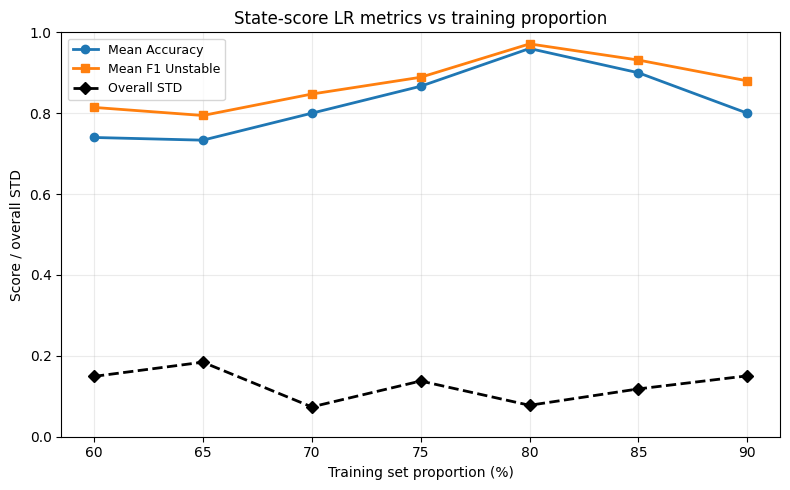

In [24]:
plot_state_score_summary(
    "./output_marker_state_score_2/lr_state_score_train_size_cv_summary_5.csv",
    out_png="./output_marker_state_score_2/lr_state_score_train_size_cv_summary_5_with_std.png",
    show_std=True,
)

# 折线图---10次求平均

In [18]:
summary_df, all_predictions_df = run_state_score_train_size_cv(
    n_splits=10,
    threshold=0.6,
    random_state=42,
    summary_path="./output_marker_state_score_2/lr_state_score_train_size_cv_summary_10.csv",
    predictions_path="./output_marker_state_score_2/lr_state_score_train_size_cv_all_fold_predictions_10.csv",
)

X_basic shape: (23, 13)
X_pb shape: (23, 67)
y distribution:
label
1    16
0     7
Name: count, dtype: int64

State-score CV | Training size = 60%, Holdout size = 40%

State-score CV | Training size = 65%, Holdout size = 35%

State-score CV | Training size = 70%, Holdout size = 30%

State-score CV | Training size = 75%, Holdout size = 25%

State-score CV | Training size = 80%, Holdout size = 19%

State-score CV | Training size = 85%, Holdout size = 15%

State-score CV | Training size = 90%, Holdout size = 9%

State-score cross-validation summary
   train_size  train_percent  n_splits  mean_accuracy  std_accuracy  \
0        0.60             60        10       0.770000      0.141814   
1        0.65             65        10       0.744444      0.157571   
2        0.70             70        10       0.814286      0.135526   
3        0.75             75        10       0.850000      0.165738   
4        0.80             80        10       0.880000      0.139841   
5        0.85         

In [ ]:
plot_state_score_summary(
    "./output_marker_state_score_2/lr_state_score_train_size_cv_summary_10.csv",
    out_png="./output_marker_state_score_2/lr_state_score_train_size_cv_summary_10_with_std.png",
    show_std=True,
)

# 折线图----100次求平均

In [20]:
summary_df, all_predictions_df = run_state_score_train_size_cv(
    n_splits=100,
    threshold=0.6,
    random_state=42,
    summary_path="./output_marker_state_score_2/lr_state_score_train_size_cv_summary_100.csv",
    predictions_path="./output_marker_state_score_2/lr_state_score_train_size_cv_all_fold_predictions_100.csv",
)

X_basic shape: (23, 13)
X_pb shape: (23, 67)
y distribution:
label
1    16
0     7
Name: count, dtype: int64

State-score CV | Training size = 60%, Holdout size = 40%

State-score CV | Training size = 65%, Holdout size = 35%

State-score CV | Training size = 70%, Holdout size = 30%

State-score CV | Training size = 75%, Holdout size = 25%

State-score CV | Training size = 80%, Holdout size = 19%

State-score CV | Training size = 85%, Holdout size = 15%

State-score CV | Training size = 90%, Holdout size = 9%

State-score cross-validation summary
   train_size  train_percent  n_splits  mean_accuracy  std_accuracy  \
0        0.60             60       100       0.812000      0.117448   
1        0.65             65       100       0.803333      0.128159   
2        0.70             70       100       0.842857      0.122672   
3        0.75             75       100       0.823333      0.149485   
4        0.80             80       100       0.868000      0.153662   
5        0.85         

In [ ]:
plot_state_score_summary(
    "./output_marker_state_score_2/lr_state_score_train_size_cv_summary_100.csv",
    out_png="./output_marker_state_score_2/lr_state_score_train_size_cv_summary_100_with_std.png",
    show_std=True,
)

## 严格 5-fold out-of-fold 验证

这个验证固定为 5 折：每一折约 80% 样本训练、20% 样本测试。每个 fold 内部重新用训练集 `X_pseudobulk_marker` fit state-score 参数，再对该 fold 的 test 样本做 out-of-fold 预测，避免 test fold 参与 state-score 标准化。

输出包括整体指标表、每折指标、每个样本的 out-of-fold unstable 概率、混淆矩阵图和样本概率点图。


In [25]:
# =========================
# Strict 5-fold out-of-fold validation
# =========================
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

STRICT5_OVERALL_PATH = f"{STATE_SCORE_OUT_DIR}/lr_state_score_strict_5fold_overall_metrics.csv"
STRICT5_FOLD_METRICS_PATH = f"{STATE_SCORE_OUT_DIR}/lr_state_score_strict_5fold_fold_metrics.csv"
STRICT5_OOF_PRED_PATH = f"{STATE_SCORE_OUT_DIR}/lr_state_score_strict_5fold_oof_predictions.csv"
STRICT5_CM_PATH = f"{STATE_SCORE_OUT_DIR}/lr_state_score_strict_5fold_confusion_matrix.csv"
STRICT5_CM_PNG = f"{STATE_SCORE_OUT_DIR}/lr_state_score_strict_5fold_confusion_matrix.png"
STRICT5_PROB_PNG = f"{STATE_SCORE_OUT_DIR}/lr_state_score_strict_5fold_oof_prob_unstable_dotplot.png"


def run_state_score_strict_5fold_oof(
    n_splits=5,
    threshold=0.5,
    random_state=42,
    overall_path=None,
    fold_metrics_path=None,
    oof_predictions_path=None,
    confusion_matrix_path=None,
):
    X_basic = pd.read_csv(f"{STATE_SCORE_OUT_DIR}/X_basic_celltype_proportion.csv", index_col=0)
    X_pb = pd.read_csv(f"{STATE_SCORE_OUT_DIR}/X_pseudobulk_marker.csv", index_col=0)
    y = pd.read_csv(f"{STATE_SCORE_OUT_DIR}/y_sample_label_numeric.csv", index_col=0).iloc[:, 0].astype(int)

    common_samples = X_basic.index.intersection(X_pb.index).intersection(y.index)
    X_basic = X_basic.loc[common_samples].sort_index()
    X_pb = X_pb.loc[common_samples].sort_index()
    y = y.loc[common_samples].sort_index()

    min_class_count = int(y.value_counts().min())
    if y.nunique() != 2 or min_class_count < n_splits:
        raise ValueError(f"5-fold CV requires both classes to have at least {n_splits} samples. y counts: {y.value_counts().to_dict()}")

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_rows = []
    oof_rows = []

    print("Strict 5-fold OOF validation")
    print("X_basic shape:", X_basic.shape)
    print("X_pb shape:", X_pb.shape)
    print("y distribution:")
    print(y.value_counts())

    for fold_id, (train_idx, test_idx) in enumerate(cv.split(X_basic, y), start=1):
        X_basic_train = X_basic.iloc[train_idx]
        X_basic_test = X_basic.iloc[test_idx]
        X_pb_train = X_pb.iloc[train_idx]
        X_pb_test = X_pb.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        state_params, marker_report = fit_state_score_params(
            X_pb_train,
            STATE_MARKERS,
            min_genes=STATE_SCORE_MIN_GENES,
        )
        X_train = make_state_score_features(X_basic_train, X_pb_train, state_params)
        X_test = make_state_score_features(X_basic_test, X_pb_test, state_params)
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

        model = build_lr_model(random_state=random_state)
        model.fit(X_train, y_train)

        prob_unstable = model.predict_proba(X_test)[:, 1]
        y_pred = (prob_unstable >= threshold).astype(int)
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

        fold_rows.append({
            "fold": fold_id,
            "n_train": len(X_train),
            "n_test": len(X_test),
            "n_train_stable": int((y_train == 0).sum()),
            "n_train_unstable": int((y_train == 1).sum()),
            "n_test_stable": int((y_test == 0).sum()),
            "n_test_unstable": int((y_test == 1).sum()),
            "n_features": X_train.shape[1],
            "n_used_states": len(state_params),
            "threshold": threshold,
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "precision_unstable": precision_score(y_test, y_pred, zero_division=0),
            "recall_unstable": recall_score(y_test, y_pred, zero_division=0),
            "specificity_stable": specificity,
            "f1_unstable": f1_score(y_test, y_pred, zero_division=0),
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        })

        fold_pred_df = pd.DataFrame({
            "fold": fold_id,
            "sample_id": X_test.index,
            "true_label_numeric": y_test.values,
            "prob_unstable": prob_unstable,
            "pred_label_numeric": y_pred,
        })
        fold_pred_df["true_label"] = fold_pred_df["true_label_numeric"].map({1: "unstable", 0: "stable"})
        fold_pred_df["pred_label"] = fold_pred_df["pred_label_numeric"].map({1: "unstable", 0: "stable"})
        fold_pred_df["pred_3class"] = fold_pred_df["prob_unstable"].apply(
            lambda p: assign_3class(p, threshold=threshold)
        )
        oof_rows.append(fold_pred_df)

    fold_metrics_df = pd.DataFrame(fold_rows)
    oof_predictions_df = pd.concat(oof_rows, axis=0, ignore_index=True)
    oof_predictions_df = oof_predictions_df.sort_values(["true_label_numeric", "prob_unstable", "sample_id"])

    y_true = oof_predictions_df["true_label_numeric"].astype(int)
    y_pred = oof_predictions_df["pred_label_numeric"].astype(int)
    prob = oof_predictions_df["prob_unstable"].astype(float)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    overall_metrics_df = pd.DataFrame([
        {"metric": "n_samples", "value": len(y_true)},
        {"metric": "n_stable", "value": int((y_true == 0).sum())},
        {"metric": "n_unstable", "value": int((y_true == 1).sum())},
        {"metric": "threshold", "value": threshold},
        {"metric": "accuracy", "value": accuracy_score(y_true, y_pred)},
        {"metric": "balanced_accuracy", "value": balanced_accuracy_score(y_true, y_pred)},
        {"metric": "precision_unstable", "value": precision_score(y_true, y_pred, zero_division=0)},
        {"metric": "recall_unstable_sensitivity", "value": recall_score(y_true, y_pred, zero_division=0)},
        {"metric": "specificity_stable", "value": specificity},
        {"metric": "f1_unstable", "value": f1_score(y_true, y_pred, zero_division=0)},
        {"metric": "roc_auc_reference", "value": roc_auc_score(y_true, prob)},
        {"metric": "tn", "value": tn},
        {"metric": "fp", "value": fp},
        {"metric": "fn", "value": fn},
        {"metric": "tp", "value": tp},
    ])

    cm_df = pd.DataFrame(
        cm,
        index=["true_stable", "true_unstable"],
        columns=["pred_stable", "pred_unstable"],
    )

    print("\nStrict 5-fold overall metrics:")
    print(overall_metrics_df)
    print("\nStrict 5-fold fold metrics:")
    print(fold_metrics_df)
    print("\nStrict 5-fold confusion matrix:")
    print(cm_df)

    if overall_path is not None:
        overall_metrics_df.to_csv(overall_path, index=False)
        print("Saved:", overall_path)
    if fold_metrics_path is not None:
        fold_metrics_df.to_csv(fold_metrics_path, index=False)
        print("Saved:", fold_metrics_path)
    if oof_predictions_path is not None:
        oof_predictions_df.to_csv(oof_predictions_path, index=False)
        print("Saved:", oof_predictions_path)
    if confusion_matrix_path is not None:
        cm_df.to_csv(confusion_matrix_path)
        print("Saved:", confusion_matrix_path)

    return overall_metrics_df, fold_metrics_df, oof_predictions_df, cm_df


def plot_strict_5fold_confusion_matrix(cm_df, out_png):
    fig, ax = plt.subplots(figsize=(3.2, 3.0), constrained_layout=True)
    im = ax.imshow(cm_df.values, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred stable", "Pred unstable"], fontsize=8)
    ax.set_yticklabels(["True stable", "True unstable"], fontsize=8)
    ax.set_title("Strict 5-fold OOF confusion matrix", fontsize=9, fontweight="bold")
    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            value = int(cm_df.iloc[i, j])
            color = "white" if value > cm_df.values.max() / 2 else "black"
            ax.text(j, i, str(value), ha="center", va="center", color=color, fontsize=10, fontweight="bold")
    ax.tick_params(axis="both", length=0)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.savefig(out_png, dpi=600, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", out_png)


def plot_strict_5fold_oof_probabilities(oof_predictions_df, out_png, threshold=0.5):
    plot_df = oof_predictions_df.copy()
    plot_df["label_order"] = plot_df["true_label_numeric"].map({0: 0, 1: 1})
    plot_df = plot_df.sort_values(["label_order", "prob_unstable", "sample_id"]).reset_index(drop=True)
    colors = plot_df["true_label_numeric"].map({0: "#4C78A8", 1: "#E45756"}).to_numpy()

    width = max(6.0, 0.28 * len(plot_df))
    fig, ax = plt.subplots(figsize=(width, 3.4), constrained_layout=True)
    ax.scatter(np.arange(len(plot_df)), plot_df["prob_unstable"], c=colors, s=34, edgecolor="black", linewidth=0.3)
    ax.axhline(threshold, color="black", linestyle="--", linewidth=1, label=f"threshold={threshold}")
    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel("OOF probability of unstable", fontsize=8, fontweight="bold")
    ax.set_xlabel("Sample", fontsize=8, fontweight="bold")
    ax.set_title("Strict 5-fold OOF unstable probability", fontsize=9, fontweight="bold")
    ax.set_xticks(np.arange(len(plot_df)))
    ax.set_xticklabels(plot_df["sample_id"], rotation=90, fontsize=6)
    ax.tick_params(axis="y", labelsize=7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, fontsize=7, loc="upper left")
    fig.savefig(out_png, dpi=600, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", out_png)


strict5_overall_df, strict5_fold_metrics_df, strict5_oof_predictions_df, strict5_cm_df = run_state_score_strict_5fold_oof(
    n_splits=5,
    threshold=0.5,
    random_state=42,
    overall_path=STRICT5_OVERALL_PATH,
    fold_metrics_path=STRICT5_FOLD_METRICS_PATH,
    oof_predictions_path=STRICT5_OOF_PRED_PATH,
    confusion_matrix_path=STRICT5_CM_PATH,
)

plot_strict_5fold_confusion_matrix(strict5_cm_df, STRICT5_CM_PNG)
plot_strict_5fold_oof_probabilities(strict5_oof_predictions_df, STRICT5_PROB_PNG, threshold=0.5)


Strict 5-fold OOF validation
X_basic shape: (23, 13)
X_pb shape: (23, 67)
y distribution:
label
1    16
0     7
Name: count, dtype: int64

Strict 5-fold overall metrics:
                         metric      value
0                     n_samples  23.000000
1                      n_stable   7.000000
2                    n_unstable  16.000000
3                     threshold   0.500000
4                      accuracy   0.913043
5             balanced_accuracy   0.857143
6            precision_unstable   0.888889
7   recall_unstable_sensitivity   1.000000
8            specificity_stable   0.714286
9                   f1_unstable   0.941176
10            roc_auc_reference   0.812500
11                           tn   5.000000
12                           fp   2.000000
13                           fn   0.000000
14                           tp  16.000000

Strict 5-fold fold metrics:
   fold  n_train  n_test  n_train_stable  ...  tn  fp  fn  tp
0     1       18       5               6  ...   1  

# 最终预测新数据 / unknown 样本

上面的交叉验证部分只是为了回答一个问题：**模型在不同训练集比例下稳不稳定**。  
真正要预测新数据时，不再留出测试集，而是：

```text
用所有已知 stable / unstable 样本训练最终模型
        ↓
把待预测样本整理成和训练集完全一样的特征列
        ↓
输出每个 sample 的 unstable 概率和预测类别
```

注意：85% 训练比例是用来评估模型稳定性的，不代表最终预测时只能用 85% 样本。最终预测通常用全部已标注样本训练模型。


### mouse

In [29]:
# ============================================================
# 最终模型训练 + state-score 预测 unknown / 新 h5ad 数据
# ============================================================
# 1. PREDICT_MODE = "existing_unknown": 使用 prepare input 里已经生成的 unknown 特征。
# 2. PREDICT_MODE = "new_h5ad": 对一个新的 h5ad 重新生成 basic + pseudobulk，
#    然后使用训练集 fit 出来的 state-score mean/std 做 transform。
# ============================================================

import os
import pandas as pd
import numpy as np
import scanpy as sc

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, confusion_matrix

# -------------------------
# 1. 参数设置
# -------------------------
PREDICT_MODE = "new_h5ad"
NEW_H5AD_PATH = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/0521_no_Basophil/output_mouse/scPoli_concat_level3_marker_allmouse_homologous.h5ad"
OUT_DIR = "./output_marker_state_score_2/mouse"
os.makedirs(OUT_DIR, exist_ok=True)

TRAIN_FEATURE_DIR = "./output_marker_state_score_2"
PRED_THRESHOLD = 0.5
HIGH_CONF_THRESHOLD = 0.8

OUT_X_BASIC_PRED = f"{OUT_DIR}/X_basic_pred_celltype_proportion.csv"
OUT_X_PB_PRED = f"{OUT_DIR}/X_pseudobulk_marker_pred.csv"
OUT_X_STATE_PRED = f"{OUT_DIR}/X_state_scores_pred.csv"
OUT_X_COMBINED_PRED = f"{OUT_DIR}/X_pred_combined_basic_plus_state_scores.csv"
FINAL_PRED_OUT = f"{OUT_DIR}/final_prediction_unstable_probability_state_score.csv"
FINAL_COEF_OUT = f"{OUT_DIR}/final_lr_state_score_feature_coefficients.csv"

SAMPLE_COL = "sample"
# CELLTYPE_COL = "cell_type_level1"
CELLTYPE_COL = "cell_type_level1_corrected"
LABEL_RAW_COL = "Plaque_type"
LABEL_COL = "Plaque_type_clean"

marker_dict = build_marker_dict_from_state_markers(STATE_MARKERS)

# -------------------------
# 2. 读取训练原料特征和标签，fit state-score 参数
# -------------------------
X_basic_train = pd.read_csv(f"{TRAIN_FEATURE_DIR}/X_basic_celltype_proportion.csv", index_col=0)
X_pb_train = pd.read_csv(f"{TRAIN_FEATURE_DIR}/X_pseudobulk_marker.csv", index_col=0)
y_train = pd.read_csv(f"{TRAIN_FEATURE_DIR}/y_sample_label_numeric.csv", index_col=0).iloc[:, 0].astype(int)

common_train = X_basic_train.index.intersection(X_pb_train.index).intersection(y_train.index)
X_basic_train = X_basic_train.loc[common_train].sort_index()
X_pb_train = X_pb_train.loc[common_train].sort_index()
y_train = y_train.loc[common_train].sort_index()

state_params_final, marker_report_final = fit_state_score_params(
    X_pb_train,
    STATE_MARKERS,
    min_genes=STATE_SCORE_MIN_GENES,
)
X_train = make_state_score_features(X_basic_train, X_pb_train, state_params_final)

print("Training X shape:", X_train.shape)
print("Training y distribution:")
print(y_train.value_counts())

# -------------------------
# 3. 用全部已标注样本训练最终模型
# -------------------------
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
    )),
])

min_class_count = int(y_train.value_counts().min())
if y_train.nunique() == 2 and min_class_count >= 2:
    n_splits = min(5, min_class_count)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_prob = cross_val_predict(final_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    cv_pred = (cv_prob >= PRED_THRESHOLD).astype(int)
    print(f"\nSample-level CV ({n_splits}-fold):")
    print("  ROC-AUC:", round(roc_auc_score(y_train, cv_prob), 3))
    print("  balanced accuracy:", round(balanced_accuracy_score(y_train, cv_pred), 3))
    print("  confusion matrix [[stable, unstable] rows]:")
    print(confusion_matrix(y_train, cv_pred, labels=[0, 1]))
else:
    print("\nSkip CV: each class needs at least 2 samples.")

final_model.fit(X_train, y_train)
print("\nFinal model fitted using all labeled stable / unstable samples.")

# -------------------------
# 4A. 情况一：预测 prepare input 里已经生成好的 unknown 特征
# -------------------------
if PREDICT_MODE == "existing_unknown":
    X_basic_pred = pd.read_csv(f"{TRAIN_FEATURE_DIR}/X_basic_unknown_celltype_proportion.csv", index_col=0)
    X_pb_pred = pd.read_csv(f"{TRAIN_FEATURE_DIR}/X_pseudobulk_marker_unknown.csv", index_col=0)
    X_pb_pred = X_pb_pred.reindex(columns=X_pb_train.columns)

    common_pred = X_basic_pred.index.intersection(X_pb_pred.index)
    X_basic_pred = X_basic_pred.loc[common_pred].reindex(columns=X_basic_train.columns, fill_value=0)
    X_pb_pred = X_pb_pred.loc[common_pred]
    pred_source = "existing_unknown"

# -------------------------
# 4B. 情况二：预测一个新的 h5ad 文件
# -------------------------
elif PREDICT_MODE == "new_h5ad":
    if not os.path.exists(NEW_H5AD_PATH):
        raise FileNotFoundError(
            f"找不到 NEW_H5AD_PATH: {NEW_H5AD_PATH}\n"
            "请把 NEW_H5AD_PATH 改成你的新 h5ad 文件路径。"
        )

    print("\nReading new h5ad...")
    adata_new = sc.read_h5ad(NEW_H5AD_PATH)

    if CELLTYPE_COL not in adata_new.obs.columns:
        raise ValueError(f"新数据 adata.obs 里缺少 CELLTYPE_COL: {CELLTYPE_COL}")
    if SAMPLE_COL not in adata_new.obs.columns:
        raise ValueError(f"新数据 adata.obs 里缺少 SAMPLE_COL: {SAMPLE_COL}")

    adata_new = adata_new[adata_new.obs[CELLTYPE_COL] != "unknown"].copy()

    if "original_gene_names" in adata_new.var.columns:
        adata_new.var["original_feature_id"] = adata_new.var_names.astype(str)
        adata_new.var_names = adata_new.var["original_gene_names"].astype(str)
        adata_new.var_names_make_unique()

    adata_new = standardize_gene_names_for_marker_features(adata_new)
    print("New adata shape after filtering unknown cell type:", adata_new.shape)

    obs_new = adata_new.obs[[SAMPLE_COL, CELLTYPE_COL]].copy()
    obs_new = obs_new.dropna(subset=[SAMPLE_COL, CELLTYPE_COL])

    cell_count_new = pd.crosstab(obs_new[SAMPLE_COL], obs_new[CELLTYPE_COL])
    cell_prop_new = cell_count_new.div(cell_count_new.sum(axis=1), axis=0)
    cell_prop_new.columns = [f"prop__{c}" for c in cell_prop_new.columns]
    X_basic_pred = cell_prop_new.reindex(columns=X_basic_train.columns, fill_value=0)

    X_pb_pred = build_pseudobulk_features(
        adata_new,
        marker_dict,
        SAMPLE_COL,
        CELLTYPE_COL,
    )
    X_pb_pred = X_pb_pred.reindex(columns=X_pb_train.columns)

    common_pred = X_basic_pred.index.intersection(X_pb_pred.index)
    X_basic_pred = X_basic_pred.loc[common_pred]
    X_pb_pred = X_pb_pred.loc[common_pred]
    pred_source = "new_h5ad"

else:
    raise ValueError('PREDICT_MODE 只能是 "existing_unknown" 或 "new_h5ad"')

# -------------------------
# 4C. 用训练集 state-score 参数 transform prediction data
# -------------------------
X_state_pred = transform_state_scores(X_pb_pred, state_params_final)
X_pred = pd.concat([X_basic_pred, X_state_pred], axis=1)
X_pred = X_pred.reindex(columns=X_train.columns, fill_value=0)

X_basic_pred.to_csv(OUT_X_BASIC_PRED)
X_pb_pred.to_csv(OUT_X_PB_PRED)
X_state_pred.to_csv(OUT_X_STATE_PRED)
X_pred.to_csv(OUT_X_COMBINED_PRED)

print("\nPrediction X shape:", X_pred.shape)
print("Prediction source:", pred_source)
print(f"Saved prediction features: {OUT_X_COMBINED_PRED}")

# -------------------------
# 5. 预测 unstable 概率
# -------------------------
prob_unstable = final_model.predict_proba(X_pred)[:, 1]

pred_df = pd.DataFrame({
    "sample_id": X_pred.index,
    "prob_unstable": prob_unstable,
})

pred_df[f"pred_label_threshold_{PRED_THRESHOLD}"] = np.where(
    pred_df["prob_unstable"] >= PRED_THRESHOLD,
    "unstable-like",
    "non-unstable",
)

pred_df["pred_3class"] = pred_df["prob_unstable"].apply(
    lambda p: assign_3class(p, threshold=PRED_THRESHOLD, high_conf_threshold=HIGH_CONF_THRESHOLD)
)
pred_df = pred_df.sort_values("prob_unstable", ascending=False)

print("\nPrediction result:")
print(pred_df)

pred_df.to_csv(FINAL_PRED_OUT, index=False)
print(f"\nSaved prediction result: {FINAL_PRED_OUT}")

# -------------------------
# 6. 导出 LogisticRegression 特征系数
# -------------------------
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": final_model.named_steps["clf"].coef_[0],
})
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)
coef_df.to_csv(FINAL_COEF_OUT, index=False)
print(f"Saved feature coefficients: {FINAL_COEF_OUT}")

print("\nTop positive features: higher value pushes prediction toward unstable")
print(coef_df.sort_values("coef", ascending=False).head(20))

print("\nTop negative features: higher value pushes prediction toward non-unstable")
print(coef_df.sort_values("coef", ascending=True).head(20))

Training X shape: (23, 25)
Training y distribution:
label
1    16
0     7
Name: count, dtype: int64

Sample-level CV (5-fold):
  ROC-AUC: 0.795
  balanced accuracy: 0.857
  confusion matrix [[stable, unstable] rows]:
[[ 5  2]
 [ 0 16]]

Final model fitted using all labeled stable / unstable samples.

Reading new h5ad...
Using adata.var['human_gene_name'] as marker gene names.
Updated 57675 gene names for marker feature alignment.
New adata shape after filtering unknown cell type: (564966, 57692)
Using log1p(raw_decontXcounts / per-cell raw_decontXcounts library size * 10000) for marker pseudobulk features.

===== marker presence check =====
Macrophage:
  present: ['PLIN2', 'TREM1', 'CCL2', 'TLR2', 'IL1B', 'TREM2', 'CD36', 'FABP4', 'FABP5', 'HMOX1', 'FTL', 'SLC40A1', 'NUPR1', 'PRDX1', 'CTSB', 'CTSD', 'LAMP2', 'LGMN', 'LIPA', 'GPNMB', 'APOC2', 'APOE', 'LRP1', 'NPC2']
  missing: ['CXCL2', 'CXCL3', 'CXCL8', 'SELENOP']
Monocyte:
  present: ['S100A8', 'S100A9', 'IL1B', 'NLRP3', 'TNF', 'CCL20

In [30]:
adata_new

AnnData object with n_obs × n_vars = 564966 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected', 'cell_type_level2', 'cell_type_level3'
    var: 'original_gene_names', 'ensemble_id', 'mouse_original_gene_names', 'human_ensemble_id', 'human_gene_name', 'original_feature_id'
    uns: 'cell_type_level1_corrected_colors', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', '

In [31]:
len(adata_new.obs['sample'].value_counts())

122

In [32]:
import pandas as pd

pred_path = "./output_marker_state_score_2/mouse/final_prediction_unstable_probability_state_score.csv"
pred = pd.read_csv(pred_path)
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/0521_no_Basophil/output_mouse/scPoli_concat_level3_marker_allmouse.h5ad")

pred_sub = pred[[
    "sample_id",
    "pred_label_threshold_0.5",
    "pred_3class"
]].rename(columns={
    "pred_label_threshold_0.5": "Plaque_type_pred",
    "pred_3class": "Plaque_type_pred_3class"
})

mapping_1 = pred_sub.set_index("sample_id")["Plaque_type_pred"]
mapping_2 = pred_sub.set_index("sample_id")["Plaque_type_pred_3class"]

adata.obs["Plaque_type_pred"] = adata.obs["sample"].map(mapping_1)
adata.obs["Plaque_type_pred_3class"] = adata.obs["sample"].map(mapping_2)

In [33]:
adata.obs['Plaque_type_pred'].value_counts()

Plaque_type_pred
non-unstable     465859
unstable-like     99107
Name: count, dtype: int64

In [34]:
### 下一步转换成 rds 文件
adata.write("./mouse_plaque_type_pred_state_score.h5ad")
adata

AnnData object with n_obs × n_vars = 564966 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected', 'cell_type_level2', 'cell_type_level3', 'Plaque_type_pred', 'Plaque_type_pred_3class'
    var: 'original_gene_names'
    uns: 'cell_type_level1_corrected_colors', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'de

### human

In [35]:
# ============================================================
# 最终模型训练 + state-score 预测 unknown / 新 h5ad 数据
# ============================================================
# 1. PREDICT_MODE = "existing_unknown": 使用 prepare input 里已经生成的 unknown 特征。
# 2. PREDICT_MODE = "new_h5ad": 对一个新的 h5ad 重新生成 basic + pseudobulk，
#    然后使用训练集 fit 出来的 state-score mean/std 做 transform。
# ============================================================

import os
import pandas as pd
import numpy as np
import scanpy as sc

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, confusion_matrix

# -------------------------
# 1. 参数设置
# -------------------------
PREDICT_MODE = "existing_unknown"
NEW_H5AD_PATH = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/0521_no_Basophil/output_mouse/scPoli_concat_level3_marker_allmouse.h5ad"
OUT_DIR = "./output_marker_state_score_2"
os.makedirs(OUT_DIR, exist_ok=True)

TRAIN_FEATURE_DIR = "./output_marker_state_score_2"
PRED_THRESHOLD = 0.5
HIGH_CONF_THRESHOLD = 0.8

OUT_X_BASIC_PRED = f"{OUT_DIR}/X_basic_pred_celltype_proportion.csv"
OUT_X_PB_PRED = f"{OUT_DIR}/X_pseudobulk_marker_pred.csv"
OUT_X_STATE_PRED = f"{OUT_DIR}/X_state_scores_pred.csv"
OUT_X_COMBINED_PRED = f"{OUT_DIR}/X_pred_combined_basic_plus_state_scores.csv"
FINAL_PRED_OUT = f"{OUT_DIR}/final_prediction_unstable_probability_state_score.csv"
FINAL_COEF_OUT = f"{OUT_DIR}/final_lr_state_score_feature_coefficients.csv"

SAMPLE_COL = "sample"
# CELLTYPE_COL = "cell_type_level1"
CELLTYPE_COL = "cell_type_level1_corrected"
LABEL_RAW_COL = "Plaque_type"
LABEL_COL = "Plaque_type_clean"

marker_dict = build_marker_dict_from_state_markers(STATE_MARKERS)

# -------------------------
# 2. 读取训练原料特征和标签，fit state-score 参数
# -------------------------
X_basic_train = pd.read_csv(f"{TRAIN_FEATURE_DIR}/X_basic_celltype_proportion.csv", index_col=0)
X_pb_train = pd.read_csv(f"{TRAIN_FEATURE_DIR}/X_pseudobulk_marker.csv", index_col=0)
y_train = pd.read_csv(f"{TRAIN_FEATURE_DIR}/y_sample_label_numeric.csv", index_col=0).iloc[:, 0].astype(int)

common_train = X_basic_train.index.intersection(X_pb_train.index).intersection(y_train.index)
X_basic_train = X_basic_train.loc[common_train].sort_index()
X_pb_train = X_pb_train.loc[common_train].sort_index()
y_train = y_train.loc[common_train].sort_index()

state_params_final, marker_report_final = fit_state_score_params(
    X_pb_train,
    STATE_MARKERS,
    min_genes=STATE_SCORE_MIN_GENES,
)
X_train = make_state_score_features(X_basic_train, X_pb_train, state_params_final)

print("Training X shape:", X_train.shape)
print("Training y distribution:")
print(y_train.value_counts())

# -------------------------
# 3. 用全部已标注样本训练最终模型
# -------------------------
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
    )),
])

min_class_count = int(y_train.value_counts().min())
if y_train.nunique() == 2 and min_class_count >= 2:
    n_splits = min(5, min_class_count)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_prob = cross_val_predict(final_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    cv_pred = (cv_prob >= PRED_THRESHOLD).astype(int)
    print(f"\nSample-level CV ({n_splits}-fold):")
    print("  ROC-AUC:", round(roc_auc_score(y_train, cv_prob), 3))
    print("  balanced accuracy:", round(balanced_accuracy_score(y_train, cv_pred), 3))
    print("  confusion matrix [[stable, unstable] rows]:")
    print(confusion_matrix(y_train, cv_pred, labels=[0, 1]))
else:
    print("\nSkip CV: each class needs at least 2 samples.")

final_model.fit(X_train, y_train)
print("\nFinal model fitted using all labeled stable / unstable samples.")

# -------------------------
# 4A. 情况一：预测 prepare input 里已经生成好的 unknown 特征
# -------------------------
if PREDICT_MODE == "existing_unknown":
    X_basic_pred = pd.read_csv(f"{TRAIN_FEATURE_DIR}/X_basic_unknown_celltype_proportion.csv", index_col=0)
    X_pb_pred = pd.read_csv(f"{TRAIN_FEATURE_DIR}/X_pseudobulk_marker_unknown.csv", index_col=0)
    X_pb_pred = X_pb_pred.reindex(columns=X_pb_train.columns)

    common_pred = X_basic_pred.index.intersection(X_pb_pred.index)
    X_basic_pred = X_basic_pred.loc[common_pred].reindex(columns=X_basic_train.columns, fill_value=0)
    X_pb_pred = X_pb_pred.loc[common_pred]
    pred_source = "existing_unknown"

# -------------------------
# 4B. 情况二：预测一个新的 h5ad 文件
# -------------------------
elif PREDICT_MODE == "new_h5ad":
    if not os.path.exists(NEW_H5AD_PATH):
        raise FileNotFoundError(
            f"找不到 NEW_H5AD_PATH: {NEW_H5AD_PATH}\n"
            "请把 NEW_H5AD_PATH 改成你的新 h5ad 文件路径。"
        )

    print("\nReading new h5ad...")
    adata_new = sc.read_h5ad(NEW_H5AD_PATH)

    if CELLTYPE_COL not in adata_new.obs.columns:
        raise ValueError(f"新数据 adata.obs 里缺少 CELLTYPE_COL: {CELLTYPE_COL}")
    if SAMPLE_COL not in adata_new.obs.columns:
        raise ValueError(f"新数据 adata.obs 里缺少 SAMPLE_COL: {SAMPLE_COL}")

    adata_new = adata_new[adata_new.obs[CELLTYPE_COL] != "unknown"].copy()

    if "original_gene_names" in adata_new.var.columns:
        adata_new.var["original_feature_id"] = adata_new.var_names.astype(str)
        adata_new.var_names = adata_new.var["original_gene_names"].astype(str)
        adata_new.var_names_make_unique()

    adata_new = standardize_gene_names_for_marker_features(adata_new)
    print("New adata shape after filtering unknown cell type:", adata_new.shape)

    obs_new = adata_new.obs[[SAMPLE_COL, CELLTYPE_COL]].copy()
    obs_new = obs_new.dropna(subset=[SAMPLE_COL, CELLTYPE_COL])

    cell_count_new = pd.crosstab(obs_new[SAMPLE_COL], obs_new[CELLTYPE_COL])
    cell_prop_new = cell_count_new.div(cell_count_new.sum(axis=1), axis=0)
    cell_prop_new.columns = [f"prop__{c}" for c in cell_prop_new.columns]
    X_basic_pred = cell_prop_new.reindex(columns=X_basic_train.columns, fill_value=0)

    X_pb_pred = build_pseudobulk_features(
        adata_new,
        marker_dict,
        SAMPLE_COL,
        CELLTYPE_COL,
    )
    X_pb_pred = X_pb_pred.reindex(columns=X_pb_train.columns)

    common_pred = X_basic_pred.index.intersection(X_pb_pred.index)
    X_basic_pred = X_basic_pred.loc[common_pred]
    X_pb_pred = X_pb_pred.loc[common_pred]
    pred_source = "new_h5ad"

else:
    raise ValueError('PREDICT_MODE 只能是 "existing_unknown" 或 "new_h5ad"')

# -------------------------
# 4C. 用训练集 state-score 参数 transform prediction data
# -------------------------
X_state_pred = transform_state_scores(X_pb_pred, state_params_final)
X_pred = pd.concat([X_basic_pred, X_state_pred], axis=1)
X_pred = X_pred.reindex(columns=X_train.columns, fill_value=0)

X_basic_pred.to_csv(OUT_X_BASIC_PRED)
X_pb_pred.to_csv(OUT_X_PB_PRED)
X_state_pred.to_csv(OUT_X_STATE_PRED)
X_pred.to_csv(OUT_X_COMBINED_PRED)

print("\nPrediction X shape:", X_pred.shape)
print("Prediction source:", pred_source)
print(f"Saved prediction features: {OUT_X_COMBINED_PRED}")

# -------------------------
# 5. 预测 unstable 概率
# -------------------------
prob_unstable = final_model.predict_proba(X_pred)[:, 1]

pred_df = pd.DataFrame({
    "sample_id": X_pred.index,
    "prob_unstable": prob_unstable,
})

pred_df[f"pred_label_threshold_{PRED_THRESHOLD}"] = np.where(
    pred_df["prob_unstable"] >= PRED_THRESHOLD,
    "unstable-like",
    "non-unstable",
)

pred_df["pred_3class"] = pred_df["prob_unstable"].apply(
    lambda p: assign_3class(p, threshold=PRED_THRESHOLD, high_conf_threshold=HIGH_CONF_THRESHOLD)
)
pred_df = pred_df.sort_values("prob_unstable", ascending=False)

print("\nPrediction result:")
print(pred_df)

pred_df.to_csv(FINAL_PRED_OUT, index=False)
print(f"\nSaved prediction result: {FINAL_PRED_OUT}")

# -------------------------
# 6. 导出 LogisticRegression 特征系数
# -------------------------
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": final_model.named_steps["clf"].coef_[0],
})
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)
coef_df.to_csv(FINAL_COEF_OUT, index=False)
print(f"Saved feature coefficients: {FINAL_COEF_OUT}")

print("\nTop positive features: higher value pushes prediction toward unstable")
print(coef_df.sort_values("coef", ascending=False).head(20))

print("\nTop negative features: higher value pushes prediction toward non-unstable")
print(coef_df.sort_values("coef", ascending=True).head(20))

Training X shape: (23, 25)
Training y distribution:
label
1    16
0     7
Name: count, dtype: int64

Sample-level CV (5-fold):
  ROC-AUC: 0.795
  balanced accuracy: 0.857
  confusion matrix [[stable, unstable] rows]:
[[ 5  2]
 [ 0 16]]

Final model fitted using all labeled stable / unstable samples.

Prediction X shape: (170, 25)
Prediction source: existing_unknown
Saved prediction features: ./output_marker_state_score_2/X_pred_combined_basic_plus_state_scores.csv

Prediction result:
       sample_id  prob_unstable pred_label_threshold_0.5  \
20   GSE143921_4   1.000000e+00            unstable-like   
19   GSE143921_3   1.000000e+00            unstable-like   
18   GSE143921_2   1.000000e+00            unstable-like   
17   GSE143921_1   1.000000e+00            unstable-like   
21   GSE143921_5   1.000000e+00            unstable-like   
..           ...            ...                      ...   
13   GSE131778_5   2.849216e-05             non-unstable   
15   GSE131778_7   2.778028e-05

In [36]:
import pandas as pd

pred_path = "./output_marker_state_score_2/final_prediction_unstable_probability_state_score.csv"
pred = pd.read_csv(pred_path)
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/0521_no_Basophil/output_allhuman/scPoli_concat_level3_marker_all_metadata.h5ad")

pred_sub = pred[[
    "sample_id",
    "pred_label_threshold_0.5",
    "pred_3class"
]].rename(columns={
    "pred_label_threshold_0.5": "Plaque_type_pred",
    "pred_3class": "Plaque_type_pred_3class"
})

mapping_1 = pred_sub.set_index("sample_id")["Plaque_type_pred"]
mapping_2 = pred_sub.set_index("sample_id")["Plaque_type_pred_3class"]

adata.obs["Plaque_type_pred"] = adata.obs["sample"].map(mapping_1)
adata.obs["Plaque_type_pred_3class"] = adata.obs["sample"].map(mapping_2)

In [37]:
adata.obs['Plaque_type_pred'].value_counts()

Plaque_type_pred
unstable-like    469285
non-unstable     321325
Name: count, dtype: int64

In [38]:
adata.write("./human_plaque_type_pred_state_score.h5ad")

#### 富集分析

用R试一下